# TP5 - Exercise 5: Pi Calculation Performance Analysis

This notebook analyzes the performance of the MPI-based parallel Pi calculation implementation using numerical integration.

## Objective
- Evaluate parallel performance for different problem sizes (N)
- Analyze speedup and efficiency across multiple processes
- Study accuracy improvement as N increases

## 1. Import Required Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Set style for better-looking plots
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

## 2. Load Performance Data

In [2]:
# Load the CSV file
df = pd.read_csv('results.csv')

# Display the first few rows
print("Performance Data:")
print(df.head(10))
print(f"\nTotal rows: {len(df)}")
print(f"N values: {sorted(df['N'].unique())}")
print(f"Process counts: {sorted(df['Num_Processes'].unique())}")

Performance Data:
          N  Num_Processes  Sequential_Time  Parallel_Time   Speedup   
0   1000000              1         0.003958       0.005203  0.760714  \
1   1000000              2         0.003958       0.001796  2.203786   
2   1000000              4         0.003958       0.001070  3.699065   
3   1000000              8         0.003958       0.001146  3.453752   
4   1000000             16         0.003958       0.001144  3.459790   
5  10000000              1         0.039329       0.037087  1.060452   
6  10000000              2         0.039329       0.023602  1.666341   
7  10000000              4         0.039329       0.009158  4.294496   
8  10000000              8         0.039329       0.009601  4.096344   
9  10000000             16         0.039329       0.011632  3.381103   

   Efficiency         Error  
0     76.0714  2.886580e-14  
1    110.1893  2.886580e-14  
2     92.4766  2.886580e-14  
3     43.1719  2.886580e-14  
4     21.6236  2.886580e-14  
5    106.

## 3. Execution Time Analysis

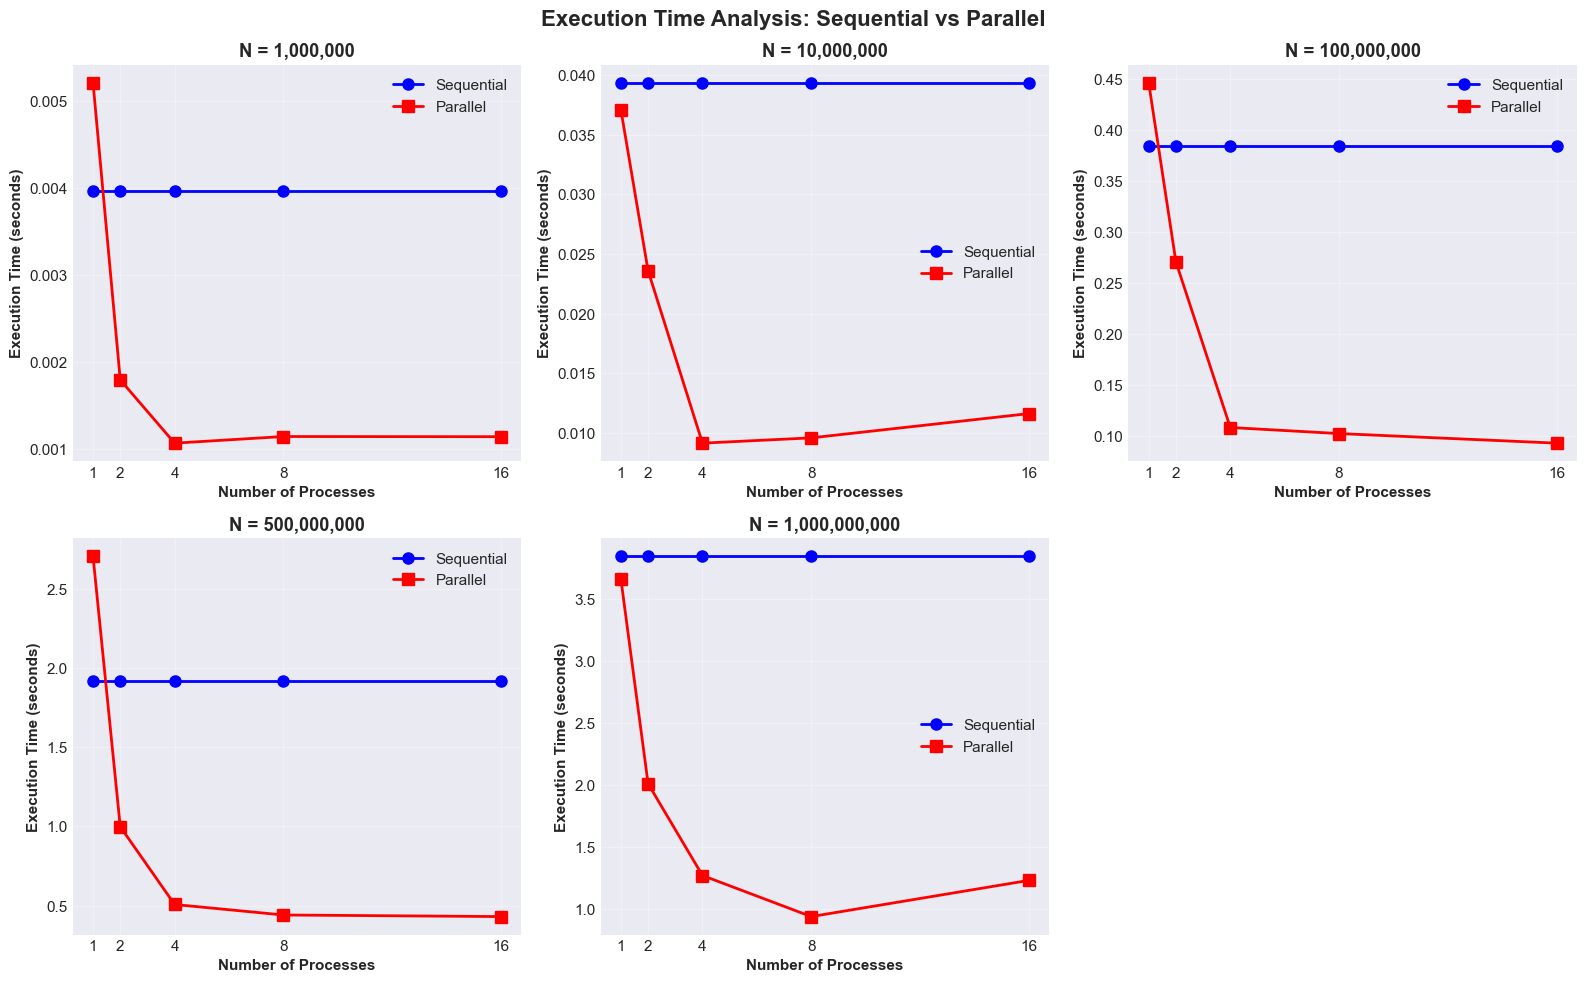

✓ Execution time comparison plot saved as 'execution_time_comparison.png'


In [3]:
# Plot execution times for each N value
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Execution Time Analysis: Sequential vs Parallel', fontsize=16, fontweight='bold')

n_values = sorted(df['N'].unique())

for idx, n in enumerate(n_values):
    ax = axes[idx // 3, idx % 3]
    
    # Filter data for this N value
    data = df[df['N'] == n].copy()
    data = data.sort_values('Num_Processes')
    
    processes = data['Num_Processes'].values
    seq_time = data['Sequential_Time'].values
    par_time = data['Parallel_Time'].values
    
    # Plot
    ax.plot(processes, seq_time, 'o-', label='Sequential', linewidth=2, markersize=8, color='blue')
    ax.plot(processes, par_time, 's-', label='Parallel', linewidth=2, markersize=8, color='red')
    
    ax.set_xlabel('Number of Processes', fontweight='bold')
    ax.set_ylabel('Execution Time (seconds)', fontweight='bold')
    ax.set_title(f'N = {n:,}', fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_xticks(processes)

# Remove extra subplot
fig.delaxes(axes[1, 2])

plt.tight_layout()
plt.savefig('execution_time_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Execution time comparison plot saved as 'execution_time_comparison.png'")

## 4. Speedup Analysis

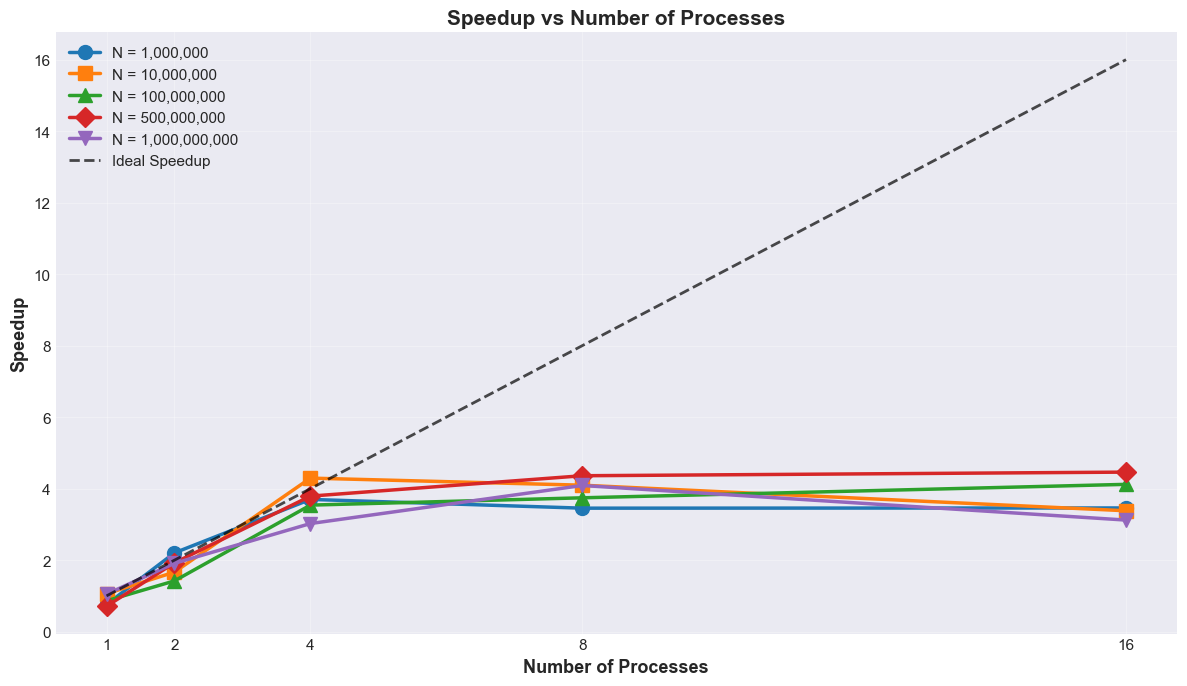

✓ Speedup comparison plot saved as 'speedup_comparison.png'


In [4]:
# Plot speedup for all N values
plt.figure(figsize=(12, 7))

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
markers = ['o', 's', '^', 'D', 'v']

for idx, n in enumerate(n_values):
    data = df[df['N'] == n].copy()
    data = data.sort_values('Num_Processes')
    
    processes = data['Num_Processes'].values
    speedup = data['Speedup'].values
    
    plt.plot(processes, speedup, marker=markers[idx], label=f'N = {n:,}', 
             linewidth=2.5, markersize=10, color=colors[idx])

# Plot ideal speedup line
ideal_processes = np.array([1, 2, 4, 8, 16])
plt.plot(ideal_processes, ideal_processes, 'k--', label='Ideal Speedup', linewidth=2, alpha=0.7)

plt.xlabel('Number of Processes', fontsize=13, fontweight='bold')
plt.ylabel('Speedup', fontsize=13, fontweight='bold')
plt.title('Speedup vs Number of Processes', fontsize=15, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.xticks([1, 2, 4, 8, 16])
plt.tight_layout()
plt.savefig('speedup_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Speedup comparison plot saved as 'speedup_comparison.png'")

## 5. Efficiency Analysis

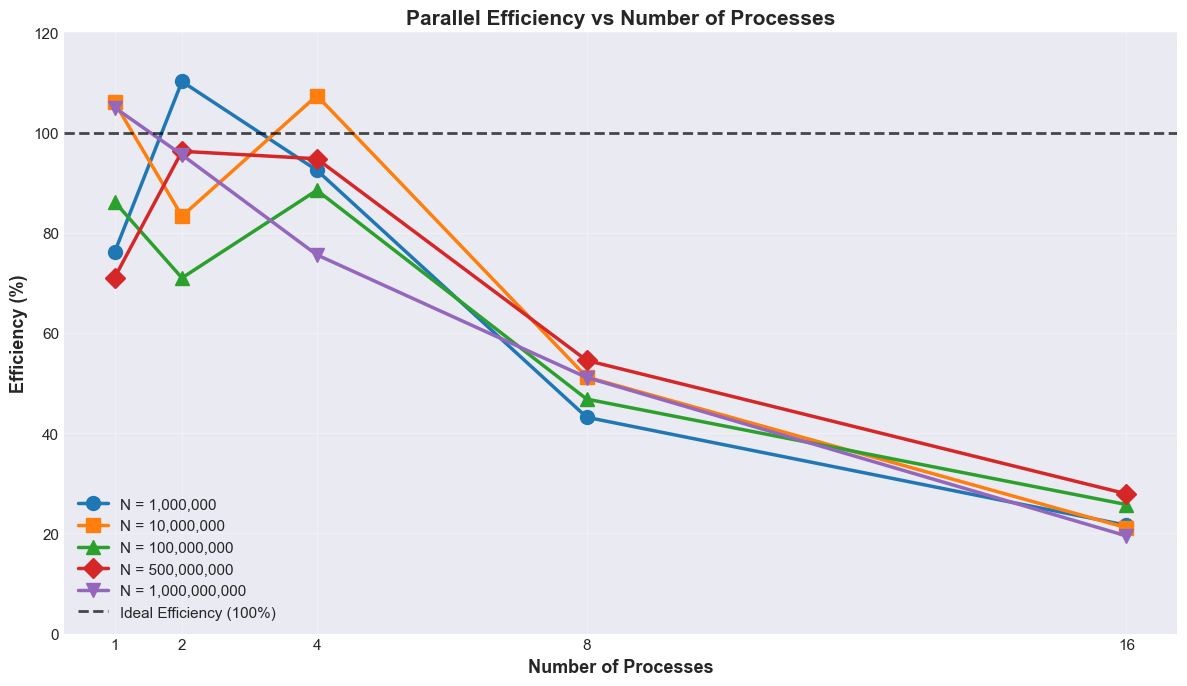

✓ Efficiency comparison plot saved as 'efficiency_comparison.png'


In [5]:
# Plot efficiency for all N values
plt.figure(figsize=(12, 7))

for idx, n in enumerate(n_values):
    data = df[df['N'] == n].copy()
    data = data.sort_values('Num_Processes')
    
    processes = data['Num_Processes'].values
    efficiency = data['Efficiency'].values
    
    plt.plot(processes, efficiency, marker=markers[idx], label=f'N = {n:,}', 
             linewidth=2.5, markersize=10, color=colors[idx])

# Plot 100% efficiency line
plt.axhline(y=100, color='k', linestyle='--', linewidth=2, alpha=0.7, label='Ideal Efficiency (100%)')

plt.xlabel('Number of Processes', fontsize=13, fontweight='bold')
plt.ylabel('Efficiency (%)', fontsize=13, fontweight='bold')
plt.title('Parallel Efficiency vs Number of Processes', fontsize=15, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.xticks([1, 2, 4, 8, 16])
plt.ylim(0, 120)
plt.tight_layout()
plt.savefig('efficiency_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Efficiency comparison plot saved as 'efficiency_comparison.png'")

## 6. Accuracy Analysis

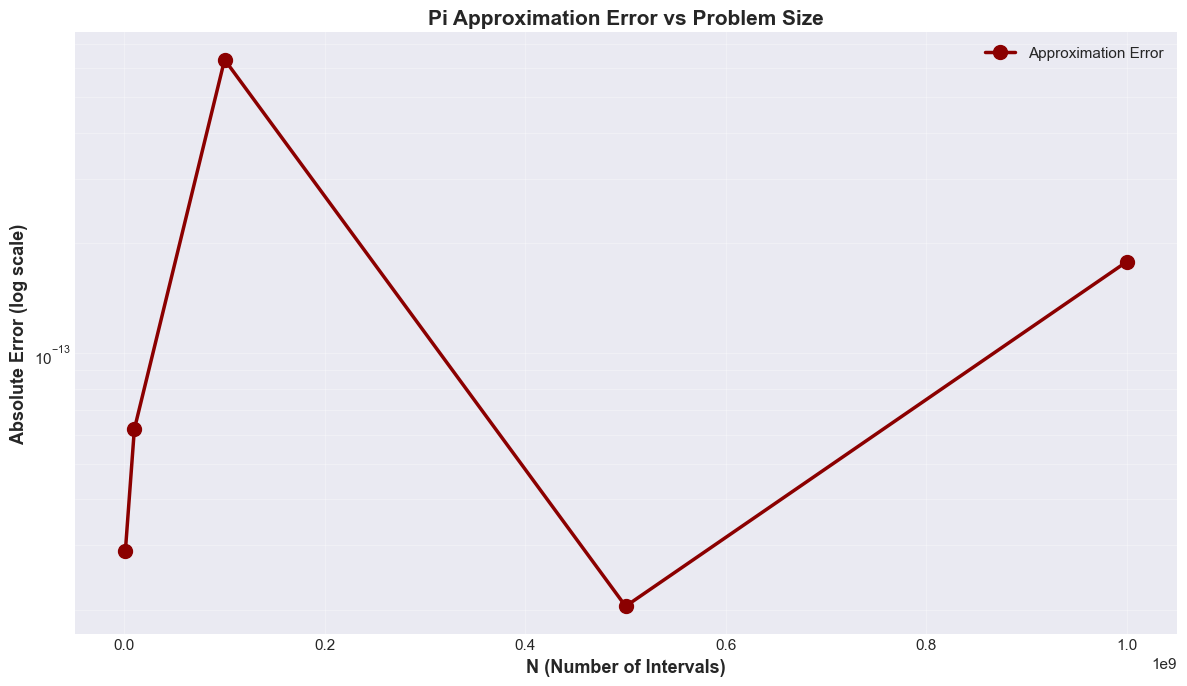

✓ Accuracy analysis plot saved as 'accuracy_analysis.png'


In [6]:
# Plot error vs N (take first process count for each N)
plt.figure(figsize=(12, 7))

# Get unique error values for each N
n_error_data = df.groupby('N')['Error'].first().reset_index()

plt.semilogy(n_error_data['N'], n_error_data['Error'], 'o-', 
             linewidth=2.5, markersize=10, color='darkred', label='Approximation Error')

plt.xlabel('N (Number of Intervals)', fontsize=13, fontweight='bold')
plt.ylabel('Absolute Error (log scale)', fontsize=13, fontweight='bold')
plt.title('Pi Approximation Error vs Problem Size', fontsize=15, fontweight='bold')
plt.grid(True, alpha=0.3, which='both')
plt.legend(fontsize=11)

# Format x-axis with scientific notation
ax = plt.gca()
ax.ticklabel_format(style='scientific', axis='x', scilimits=(0,0))

plt.tight_layout()
plt.savefig('accuracy_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Accuracy analysis plot saved as 'accuracy_analysis.png'")

## 7. Parallel Time Analysis

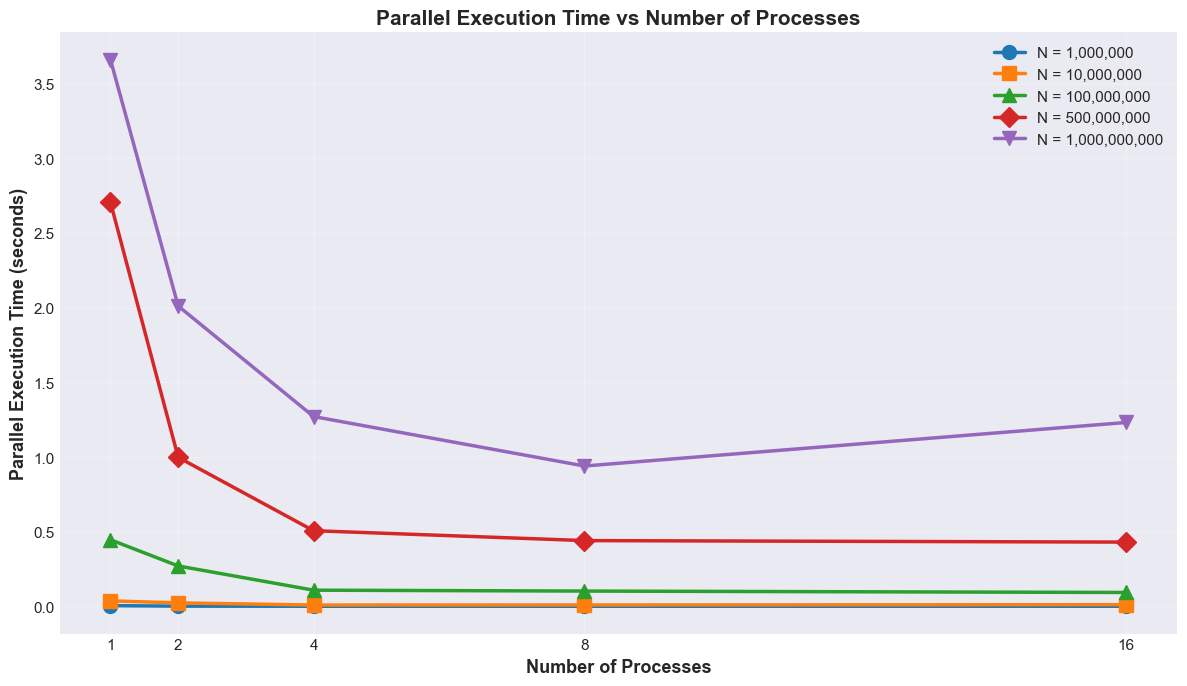

✓ Parallel time comparison plot saved as 'parallel_time_comparison.png'


In [7]:
# Plot parallel execution time for all N values
plt.figure(figsize=(12, 7))

for idx, n in enumerate(n_values):
    data = df[df['N'] == n].copy()
    data = data.sort_values('Num_Processes')
    
    processes = data['Num_Processes'].values
    par_time = data['Parallel_Time'].values
    
    plt.plot(processes, par_time, marker=markers[idx], label=f'N = {n:,}', 
             linewidth=2.5, markersize=10, color=colors[idx])

plt.xlabel('Number of Processes', fontsize=13, fontweight='bold')
plt.ylabel('Parallel Execution Time (seconds)', fontsize=13, fontweight='bold')
plt.title('Parallel Execution Time vs Number of Processes', fontsize=15, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.xticks([1, 2, 4, 8, 16])
plt.tight_layout()
plt.savefig('parallel_time_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Parallel time comparison plot saved as 'parallel_time_comparison.png'")

## 8. Combined Analysis Dashboard

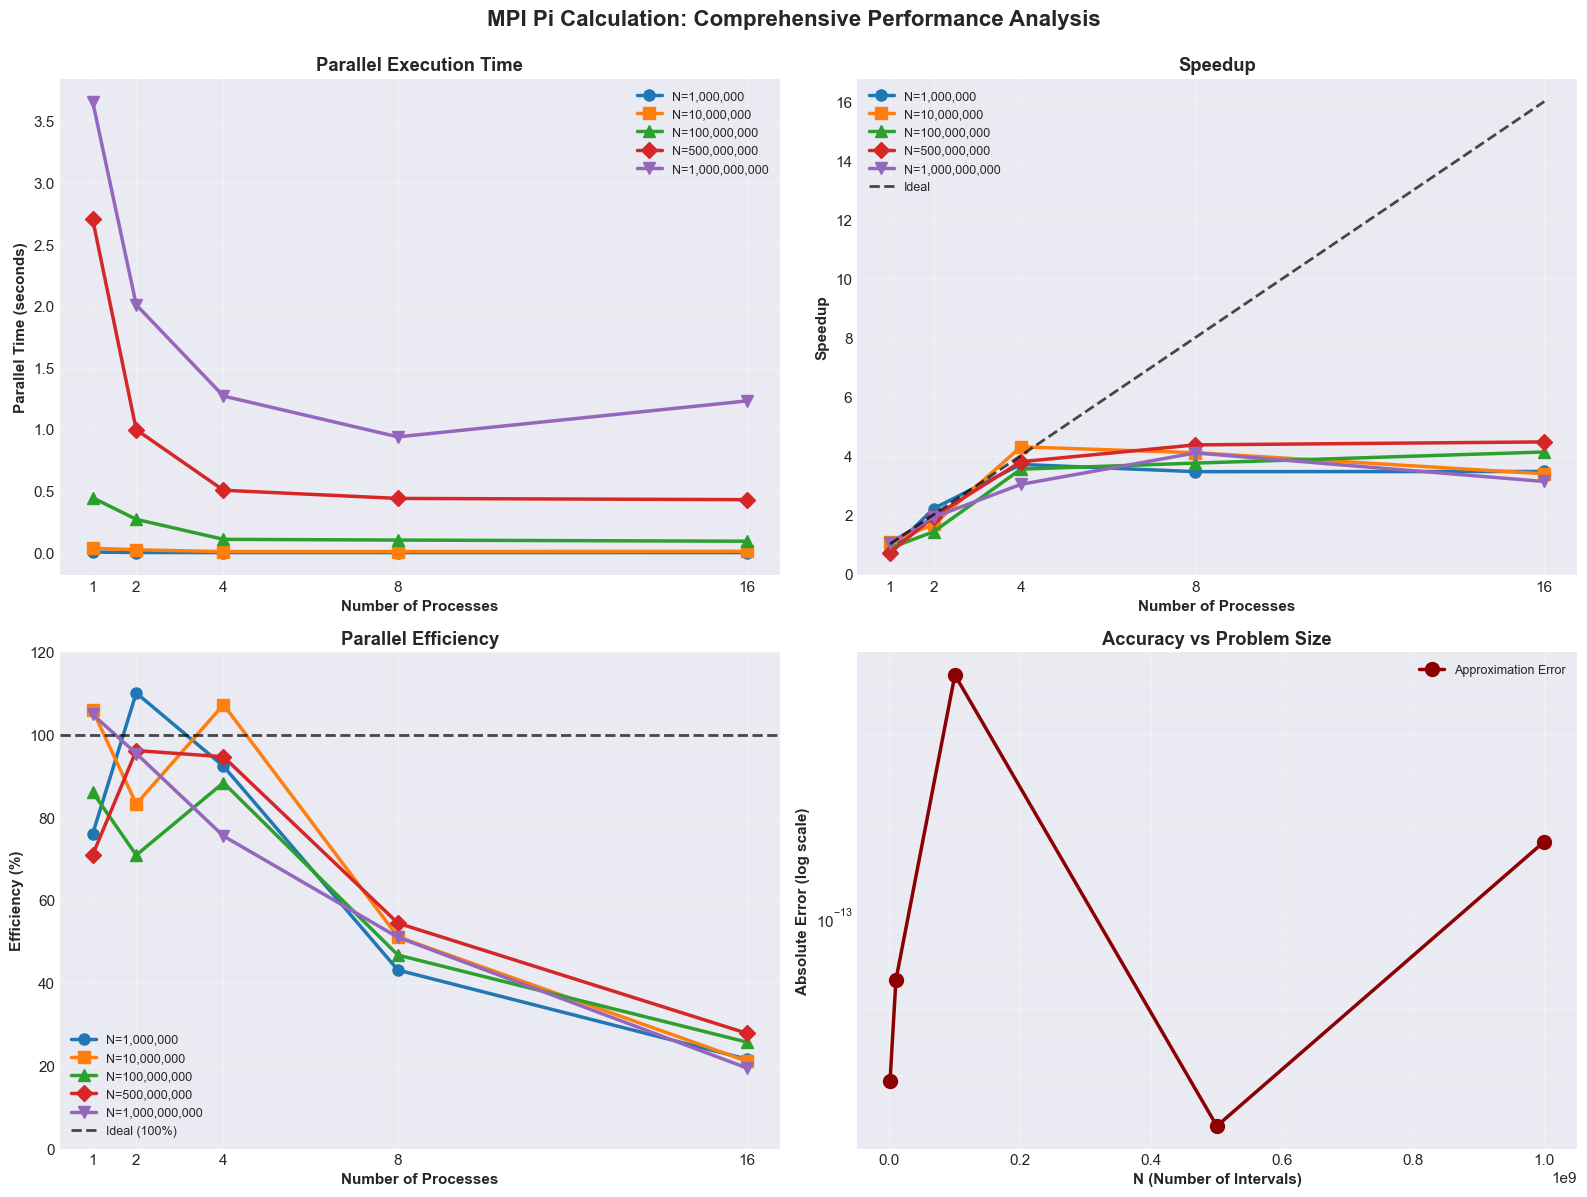

✓ Combined analysis dashboard saved as 'combined_analysis.png'


In [8]:
# Create a comprehensive dashboard
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('MPI Pi Calculation: Comprehensive Performance Analysis', 
             fontsize=16, fontweight='bold', y=0.995)

# Subplot 1: Parallel execution time
ax1 = axes[0, 0]
for idx, n in enumerate(n_values):
    data = df[df['N'] == n].sort_values('Num_Processes')
    ax1.plot(data['Num_Processes'], data['Parallel_Time'], marker=markers[idx], 
             label=f'N={n:,}', linewidth=2.5, markersize=8, color=colors[idx])
ax1.set_xlabel('Number of Processes', fontweight='bold')
ax1.set_ylabel('Parallel Time (seconds)', fontweight='bold')
ax1.set_title('Parallel Execution Time', fontweight='bold')
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)
ax1.set_xticks([1, 2, 4, 8, 16])

# Subplot 2: Speedup
ax2 = axes[0, 1]
for idx, n in enumerate(n_values):
    data = df[df['N'] == n].sort_values('Num_Processes')
    ax2.plot(data['Num_Processes'], data['Speedup'], marker=markers[idx], 
             label=f'N={n:,}', linewidth=2.5, markersize=8, color=colors[idx])
ideal_p = np.array([1, 2, 4, 8, 16])
ax2.plot(ideal_p, ideal_p, 'k--', label='Ideal', linewidth=2, alpha=0.7)
ax2.set_xlabel('Number of Processes', fontweight='bold')
ax2.set_ylabel('Speedup', fontweight='bold')
ax2.set_title('Speedup', fontweight='bold')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)
ax2.set_xticks([1, 2, 4, 8, 16])

# Subplot 3: Efficiency
ax3 = axes[1, 0]
for idx, n in enumerate(n_values):
    data = df[df['N'] == n].sort_values('Num_Processes')
    ax3.plot(data['Num_Processes'], data['Efficiency'], marker=markers[idx], 
             label=f'N={n:,}', linewidth=2.5, markersize=8, color=colors[idx])
ax3.axhline(y=100, color='k', linestyle='--', linewidth=2, alpha=0.7, label='Ideal (100%)')
ax3.set_xlabel('Number of Processes', fontweight='bold')
ax3.set_ylabel('Efficiency (%)', fontweight='bold')
ax3.set_title('Parallel Efficiency', fontweight='bold')
ax3.legend(fontsize=9)
ax3.grid(True, alpha=0.3)
ax3.set_xticks([1, 2, 4, 8, 16])
ax3.set_ylim(0, 120)

# Subplot 4: Error vs N
ax4 = axes[1, 1]
n_error_data = df.groupby('N')['Error'].first().reset_index()
ax4.semilogy(n_error_data['N'], n_error_data['Error'], 'o-', 
             linewidth=2.5, markersize=10, color='darkred', label='Approximation Error')
ax4.set_xlabel('N (Number of Intervals)', fontweight='bold')
ax4.set_ylabel('Absolute Error (log scale)', fontweight='bold')
ax4.set_title('Accuracy vs Problem Size', fontweight='bold')
ax4.legend(fontsize=9)
ax4.grid(True, alpha=0.3, which='both')
ax4.ticklabel_format(style='scientific', axis='x', scilimits=(0,0))

plt.tight_layout()
plt.savefig('combined_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Combined analysis dashboard saved as 'combined_analysis.png'")

## 9. Statistical Summary

In [9]:
# Summary statistics
print("="*90)
print("PERFORMANCE SUMMARY")
print("="*90)

for n in n_values:
    data = df[df['N'] == n].copy()
    data = data.sort_values('Num_Processes')
    
    print(f"\nN = {n:,}")
    print("-" * 90)
    print(f"{'Procs':<8} {'Seq Time (s)':<15} {'Par Time (s)':<15} {'Speedup':<12} {'Efficiency (%)':<15} {'Error':<15}")
    print("-" * 90)
    
    for _, row in data.iterrows():
        print(f"{int(row['Num_Processes']):<8} {row['Sequential_Time']:<15.6f} {row['Parallel_Time']:<15.6f} "
              f"{row['Speedup']:<12.3f} {row['Efficiency']:<15.2f} {row['Error']:<15.6e}")
    
    # Best performance
    best_speedup_row = data.loc[data['Speedup'].idxmax()]
    best_efficiency_row = data.loc[data['Efficiency'].idxmax()]
    
    print(f"\n  → Best Speedup: {best_speedup_row['Speedup']:.3f}x with {int(best_speedup_row['Num_Processes'])} processes")
    print(f"  → Best Efficiency: {best_efficiency_row['Efficiency']:.2f}% with {int(best_efficiency_row['Num_Processes'])} processes")
    print(f"  → Approximation Error: {data['Error'].iloc[0]:.6e}")

print("\n" + "="*90)

PERFORMANCE SUMMARY

N = 1,000,000
------------------------------------------------------------------------------------------
Procs    Seq Time (s)    Par Time (s)    Speedup      Efficiency (%)  Error          
------------------------------------------------------------------------------------------
1        0.003958        0.005203        0.761        76.07           2.886580e-14   
2        0.003958        0.001796        2.204        110.19          2.886580e-14   
4        0.003958        0.001070        3.699        92.48           2.886580e-14   
8        0.003958        0.001146        3.454        43.17           2.886580e-14   
16       0.003958        0.001144        3.460        21.62           2.886580e-14   

  → Best Speedup: 3.699x with 4 processes
  → Best Efficiency: 110.19% with 2 processes
  → Approximation Error: 2.886580e-14

N = 10,000,000
------------------------------------------------------------------------------------------
Procs    Seq Time (s)    Par Time

## 10. Accuracy vs Computational Cost

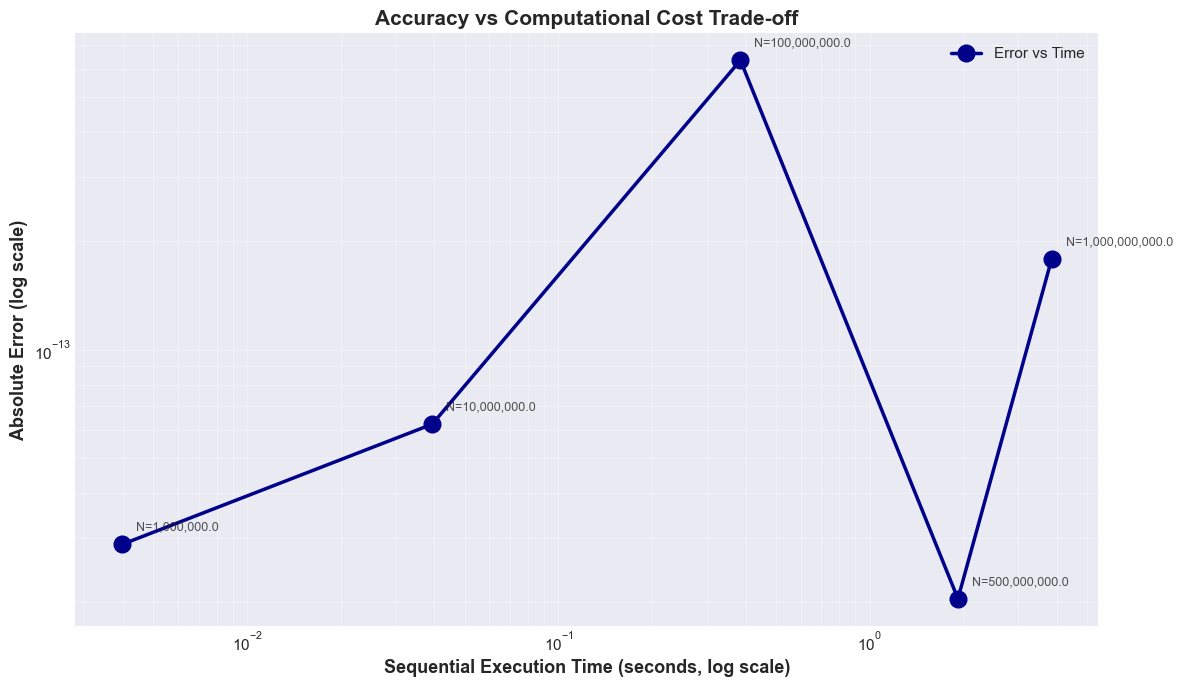

✓ Accuracy vs cost trade-off plot saved as 'accuracy_cost_tradeoff.png'


In [10]:
# Plot error vs computational cost (sequential time)
plt.figure(figsize=(12, 7))

# Get data for 1 process (represents sequential performance)
seq_data = df[df['Num_Processes'] == 1].copy()
seq_data = seq_data.sort_values('N')

plt.loglog(seq_data['Sequential_Time'], seq_data['Error'], 'o-', 
           linewidth=2.5, markersize=12, color='darkblue', label='Error vs Time')

# Annotate each point with N value
for _, row in seq_data.iterrows():
    plt.annotate(f"N={row['N']:,}", 
                xy=(row['Sequential_Time'], row['Error']),
                xytext=(10, 10), textcoords='offset points',
                fontsize=9, alpha=0.8)

plt.xlabel('Sequential Execution Time (seconds, log scale)', fontsize=13, fontweight='bold')
plt.ylabel('Absolute Error (log scale)', fontsize=13, fontweight='bold')
plt.title('Accuracy vs Computational Cost Trade-off', fontsize=15, fontweight='bold')
plt.grid(True, alpha=0.3, which='both')
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig('accuracy_cost_tradeoff.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Accuracy vs cost trade-off plot saved as 'accuracy_cost_tradeoff.png'")

## 11. Key Observations

### Expected Behavior:
1. **Speedup**: Should increase with more processes, approaching ideal linear speedup for larger N values
2. **Efficiency**: Better efficiency for larger N (more computation per communication)
3. **Problem Size Impact**: Larger N values should benefit more from parallelization
4. **Accuracy**: Error decreases as N increases (more intervals = better approximation)
5. **Scalability**: Super-linear speedup might occur due to cache effects for smaller problems

### Analysis Points:
- **Communication Overhead**: MPI_Reduce has minimal overhead for this computation-intensive task
- **Load Balancing**: Work is evenly distributed when N is divisible by num_processes
- **Granularity**: Larger N provides better computation-to-communication ratio
- **Oversubscription Effect**: Performance with 8 and 16 processes may plateau or degrade
- **Numerical Accuracy**: Error reaches machine precision limits (around 10^-13 to 10^-14)

### Performance Insights:
- For small N (1M): Communication overhead dominates, limited speedup
- For large N (1B): Better parallel efficiency, computation dominates communication
- Optimal process count depends on N and hardware configuration
- Trade-off between accuracy and computational cost